<a href="https://colab.research.google.com/github/Prachetaganguly/pytorch-for-neural-networks/blob/main/PINN_euler_beam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

In [26]:
#Euler-Bernoulli eqn for Cantilever Beam
!pip install deepxde
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import torch


Governing Differential eqn

In [27]:
def pde(x,y):
  # First derivative
  dy_x = dde.grad.jacobian(y, x, i=0)
  # Second derivative
  dy_xx = dde.grad.jacobian(dy_x, x, i=0)
  # Third derivative
  dy_xxx = dde.grad.jacobian(dy_xx, x, i=0)
  # Fourth derivative
  dy_xxxx = dde.grad.jacobian(dy_xxx, x, i=0)
  return dy_xxxx+1

Dirichlet and Neumann bc on the left boundary

In [28]:
def boundary_value_l(X):
  return 0
def boundary_l(x, on_boundary):
  return on_boundary and np.isclose(x[0],0) #It tells DeepXDE:“Apply the boundary condition ONLY at x = 0"

Custom boundary condition on the right boundary

In [29]:
#second derivative
def ddy(x,y):
  # Calculate first derivative
  dy_x = dde.grad.jacobian(y, x, i=0)
  # Calculate second derivative
  ddy_xx = dde.grad.jacobian(dy_x, x, i=0)
  return ddy_xx

#third derivative
def dddy(x,y):
  # Calculate first derivative
  dy_x = dde.grad.jacobian(y, x, i=0)
  # Calculate second derivative
  ddy_xx = dde.grad.jacobian(dy_x, x, i=0)
  # Calculate third derivative
  dddy_xxx = dde.grad.jacobian(ddy_xx, x, i=0)
  return dddy_xxx

#define the functions explicitly
def boundary_second_derivative(x,y,_):
  return ddy(x,y)

def boundary_third_derivative(x,y,_):
  return dddy(x,y)

#define the boundary condition
def boundary_r(x, on_boundary):
  return on_boundary and np.isclose(x[0],1) #It tells DeepXDE:“Apply the boundary condition ONLY at x = 1"

The exact solution

In [30]:
#Analytical solution
def func(x):
  return -(x**4)/24+x**3/6-x**2/4

Main PINN Model

In [31]:
geom=dde.geometry.Interval(0,1)

DirichletBC and NeumannBC in DeepXDE

In [32]:
bc_dbc=dde.icbc.DirichletBC(geom, boundary_value_l,boundary_l)
bc_nbc=dde.icbc.NeumannBC(geom, boundary_value_l,boundary_l)

In [33]:
bc_obc1=dde.icbc.OperatorBC(geom,boundary_second_derivative,boundary_r) #built-in class for enforcing value of function
bc_obc2=dde.icbc.OperatorBC(geom,boundary_third_derivative,boundary_r) #built-in class for enforcing normal derivative


In [34]:
data=dde.data.PDE(geom,pde,[bc_dbc,bc_nbc,bc_obc1,bc_obc2],15,2, solution=func, num_test=100)
#num_test refers no of points in the domain n boundary combines

In [35]:
layer_size=[1]+[30]*3+[1]
activation="tanh"
initializer="Glorot uniform"
net=dde.nn.FNN(layer_size,activation,initializer)

model=dde.Model(data,net)
model.compile("adam",lr=0.001,metrics=["l2 relative error"])
losshistory, train_state=model.train(iterations=3000)

Compiling model...
'compile' took 0.000144 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [5.87e-01, 0.00e+00, 3.03e-01, 3.61e-02, 1.79e-03]    [5.74e-01, 0.00e+00, 3.03e-01, 3.61e-02, 1.79e-03]    [3.76e+00]    
1000      [1.30e-04, 1.94e-12, 2.60e-08, 3.32e-07, 4.43e-07]    [9.27e-05, 1.94e-12, 2.60e-08, 3.32e-07, 4.43e-07]    [3.29e-04]    
2000      [8.76e-05, 8.29e-09, 2.01e-07, 6.70e-08, 2.85e-10]    [6.93e-05, 8.29e-09, 2.01e-07, 6.70e-08, 2.85e-10]    [3.13e-03]    
3000      [6.57e-05, 7.64e-09, 1.60e-06, 1.26e-06, 1.87e-08]    [5.53e-05, 7.64e-09, 1.60e-06, 1.26e-06, 1.87e-08]    [1.02e-02]    

Best model at step 3000:
  train loss: 6.86e-05
  test loss: 5.82e-05
  test metric: [1.02e-02]

'train' took 24.307156 s



Visualisations

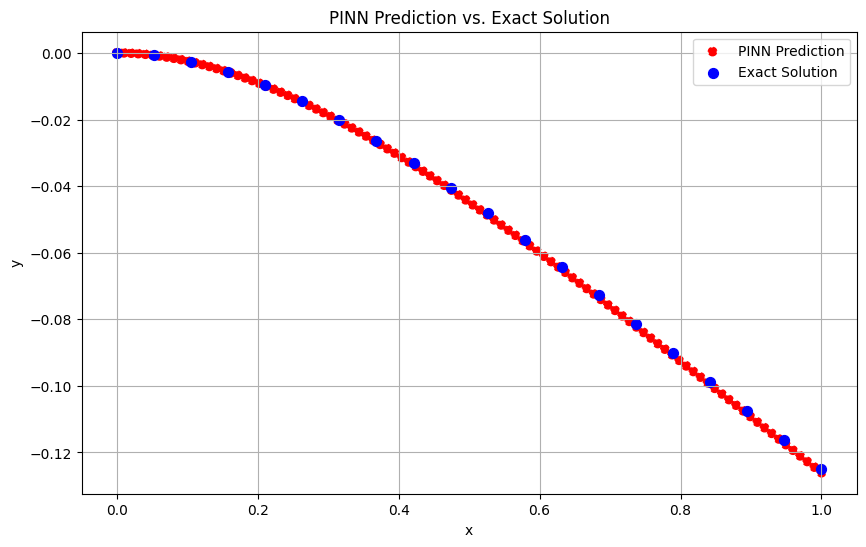

In [37]:
x_values_pinn=np.linspace(0,1,100).reshape(-1,1)
x_values_exact=np.linspace(0,1,20).reshape(-1,1)

#Use the trained model to predict the output x_values
y_pred=model.predict(x_values_pinn)

#Compute the exact solution for the same x_values
y_exact=func(x_values_exact)

#Plot the PINN prediction vs. the exact solution
plt.figure(figsize=(10,6))
plt.scatter(x_values_pinn,y_pred,label="PINN Prediction",color="red", linestyle="--")
plt.scatter(x_values_exact, y_exact, label="Exact Solution", color="blue", marker="o", s=50)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Prediction vs. Exact Solution")
plt.legend()
plt.grid()
plt.show()